In [2]:
"""data_explore.py
This notebook is meant only for preliminary data exploration and will not 
be used in model training. 
"""

# Standard imports 
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_theme("paper", "whitegrid")

In [6]:
# Read data
project_path = "../.."
data_dir = os.path.join(project_path, "data"); 
thermal_data_path = os.path.join(data_dir, "thermal", "thermal_all_data.csv")
solvent_data_path = os.path.join(data_dir, "solvent", "solvent_all_data.csv")

thermal_all_df = pd.read_csv(thermal_data_path)
solvent_all_df = pd.read_csv(solvent_data_path)
thermal_all_df.head()

,f-chi-0-all,f-chi-1-all,f-chi-2-all,f-chi-3-all,f-Z-0-all,f-Z-1-all,f-Z-2-all,f-Z-3-all,f-I-0-all,f-I-1-all,...,GPONAV,GPOV,GSA,POAV,POAV_vol_frac,PONAV,PONAV_vol_frac,VPOV,VSA,cell_v
0,216.7340,413.5808,955.7128,1458.0352,2598.0,6408.0,9508.0,10848.0,26.0,56.0,...,0.066954,0.066954,0.00,0.00,0.0000,134.811,0.1021,0.1021,0.00,1320.38
1,145.4550,245.2560,615.8416,635.2960,2484.0,5668.0,6624.0,7136.0,16.0,36.0,...,0.083972,0.505096,1304.51,1917.20,0.3997,382.289,0.0797,0.4794,1238.14,4796.60
2,147.7188,267.5904,629.3056,653.4592,2692.0,6060.0,6816.0,7392.0,16.0,36.0,...,0.078630,0.488835,1303.97,1900.15,0.4017,364.230,0.0770,0.4787,1276.93,4730.26
3,245.0088,405.0944,1605.5168,2109.1328,11522.0,20736.0,41472.0,45312.0,26.0,64.0,...,0.071692,0.071692,0.00,0.00,0.0000,259.019,0.1112,0.1112,0.00,2329.31
4,123.8472,238.3232,698.9936,421.0560,3057.0,7040.0,5936.0,2304.0,13.0,32.0,...,0.000000,0.929607,2363.59,9728.24,0.6269,0.000,0.0000,0.6269,1593.94,15518.00


## Thermal Stability Data

### f- Data 

- f- data are f-scores? 
- f-chi: medians 177, 330, 793, 916, left-skewed
- f-Z: medians 3812, 7351, 10530, 9632, left-skewed
- f-I: medians 20 48 90 116, left-skewed
- f-T: medians 144, 407, 579, 556, left-skewed
- f-S: ...

### Other Data 

These data are likely related to some distribution, or some chemical attributes extracted from the cif files. 

- mc-: McNemar's test? 
- D_mc-: ??
- f-lig-: ??
- lc-: ??
- D_lc-: ??
- func-: ??
- D_func-: ??
- Df, Di, Dif: some kind of distribution data ??

### MOF Features 

These must have been extracted from the cif files. See [feature_extraction.py](../model_features/feature_extraction.py). 

GPOAV, GPONAV, GPOV, GSA, POAV, POAV_vol_frac, PONAV, PONAV_vol_frac, VPOV, VSA, cell_v

## Labels 

- T: thermal breakdown temperature

### Discard 

- filename 
- 0 
- CoRE_name
- refcode

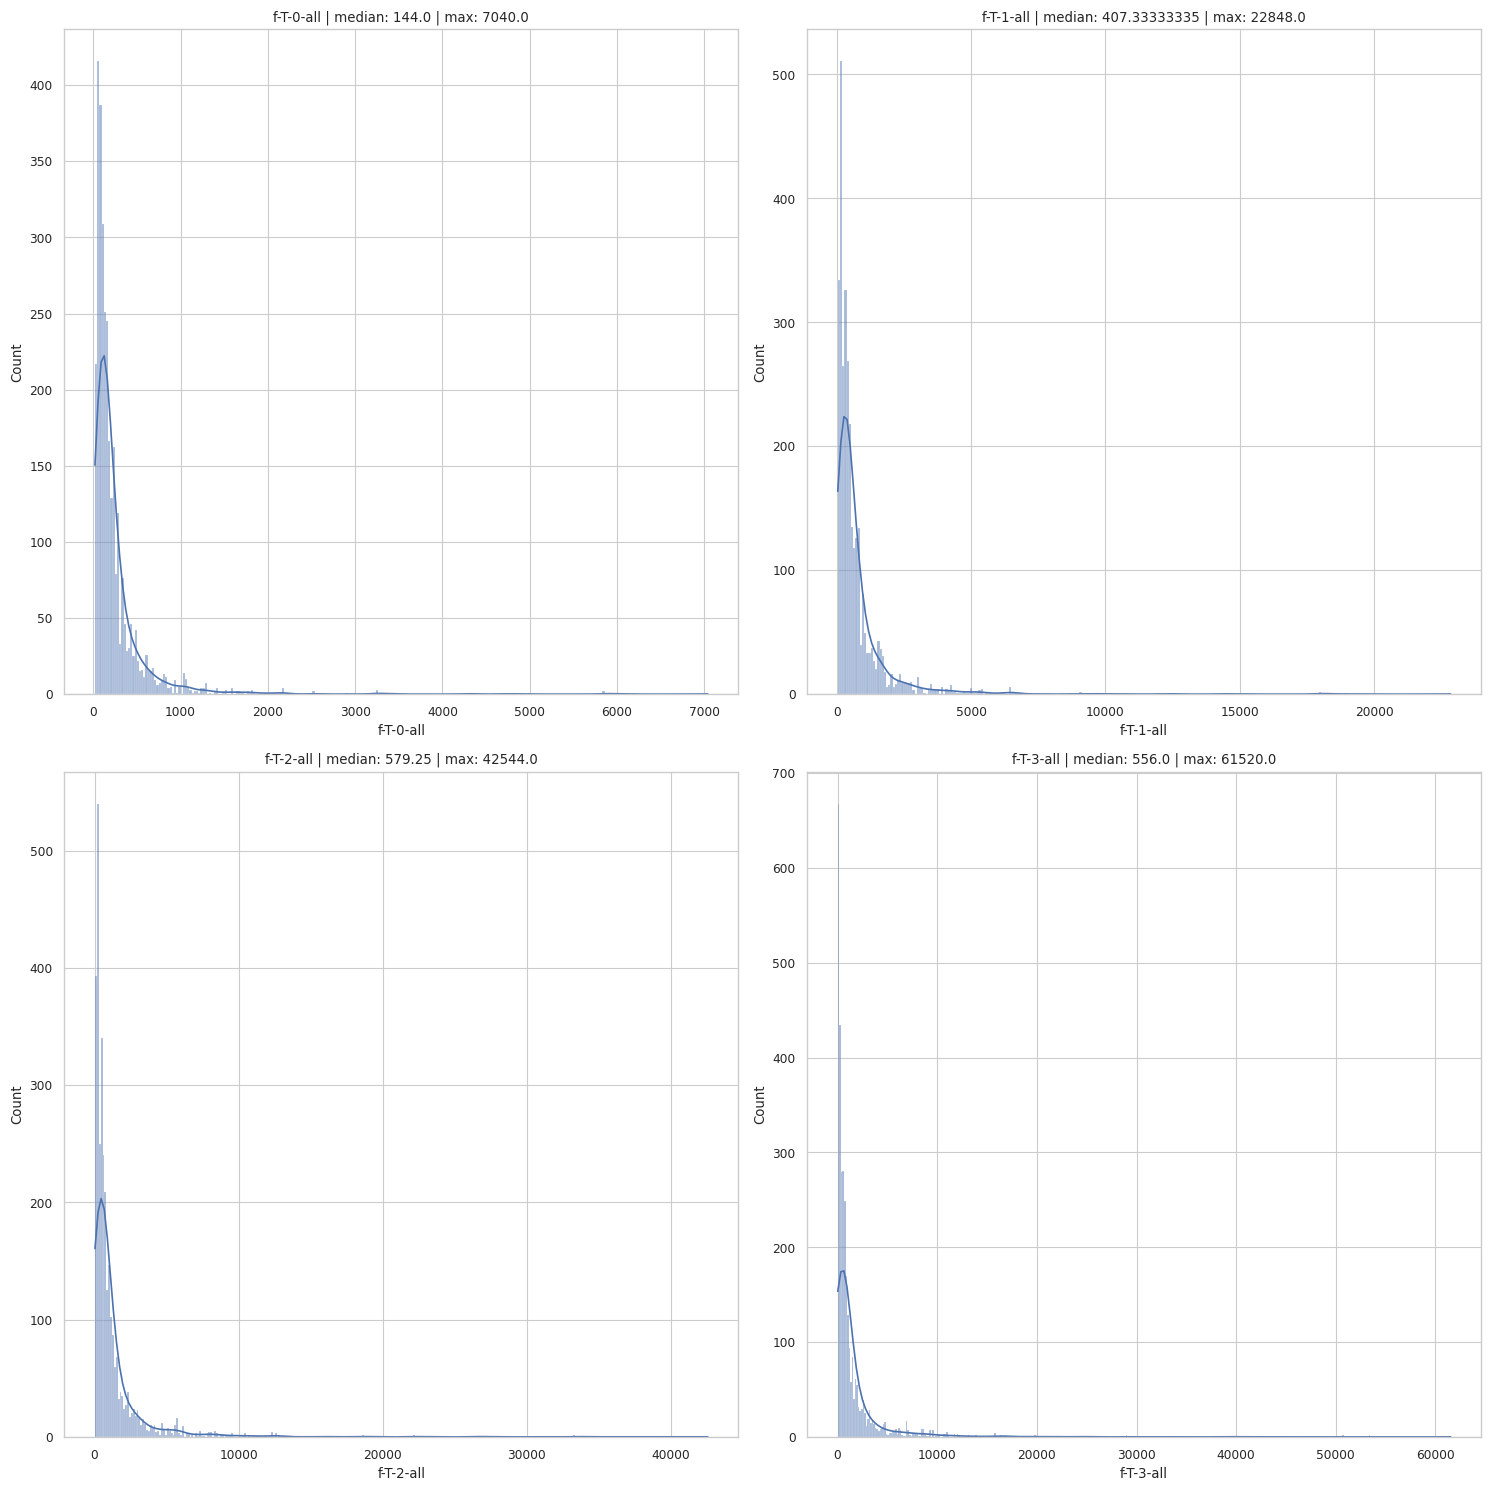

In [4]:
thermal_feature_names = thermal_all_df.columns

# Filter columns that start with "f-chi"
prefix_columns = [col for col in thermal_feature_names if col.startswith("f-T")]
num_columns = len(prefix_columns)
n = int(np.ceil(np.sqrt(num_columns)))

# Create subplots
fig1, axes1 = plt.subplots(n, n, figsize=(15, 15))
axes1 = axes1.flatten()

# Plot histograms
for i, col in enumerate(prefix_columns):
    sns.histplot(thermal_all_df[col], ax=axes1[i], kde=True)
    axes1[i].set_title(col + f" | median: {thermal_all_df[col].median()} | max: {thermal_all_df[col].max()}")

for j in range(i + 1, n * n):
    fig1.delaxes(axes1[j])
plt.tight_layout()

In [5]:
# Correlation 
sns.heatmap(thermal_all_df.corr())

ValueError: could not convert string to float: 'ABAVIJ_clean.cif'

In [ ]:
# Export raw features: features that I am certain are from the cif files 
thermal_raw_df = thermal_all_df[["GPOAV", "GPONAV", "GPOV", "GSA", "POAV", "POAV_vol_frac", "PONAV", "PONAV_vol_frac", "VPOV", "VSA", "cell_v"]]
# thermal_raw_df.to_pickle(os.path.join(data_dir, "thermal_raw.pickle"))

### Solvent removal stability model

In [9]:
solvent_all_df.head()

,Unnamed: 0,CoRE_name,refcode,doi,flag,Df,Di,Dif,GPOAV,GPONAV,...,D_func-S-0-all,D_func-S-1-all,D_func-S-2-all,D_func-S-3-all,D_func-alpha-0-all,D_func-alpha-1-all,D_func-alpha-2-all,D_func-alpha-3-all,filename,0
0,0,ABAYOU_clean,ABAYOU,10.1021/acs.cgd.6b00776,1,4.50635,11.24900,11.24900,0.410205,0.078630,...,0,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,ABAYOU_clean.cif,NaN
1,1,ACOLEL_clean,ACOLEL,10.1039/c2jm34349e,1,2.78217,4.00255,3.89811,0.000000,0.006668,...,0,0.340000,0.330000,0.710000,0,-4.907110,-6.857110,-3.964220,ACOLEL_clean.cif,NaN
2,2,ACOLIP_clean,ACOLIP,10.1039/c2jm34349e,1,3.57647,4.91034,4.78103,0.000000,0.219727,...,0,0.080000,0.720000,0.196667,0,-7.535703,-1.414220,-7.921407,ACOLIP_clean.cif,NaN
3,3,ACOLOV_clean,ACOLOV,10.1039/c2jm35273g,1,5.53552,8.42183,8.41851,0.619172,0.000000,...,0,-0.071111,0.542222,0.302222,0,-10.666667,-13.257084,-25.609480,ACOLOV_clean.cif,NaN
4,4,ADUWON_clean,ADUWON,10.1002/chem.201300144,-1,5.99291,16.38544,16.38544,1.306680,0.000000,...,0,-0.060000,0.280000,0.240000,0,-9.000000,-11.207110,-17.207110,ADUWON_clean.cif,NaN


In [12]:
removed_cols = ["Unnamed: 0", "doi", "filename", "0", "CoRE_name", "refcode", "name"]
solvent_clean_df = solvent_all_df.loc[:, ~solvent_all_df.columns.isin(removed_cols)]
solvent_clean_df.columns[solvent_clean_df.isna().any()].tolist() # List columns with nan values
solvent_clean_df.head()

,flag,Df,Di,Dif,GPOAV,GPONAV,GPOV,GSA,POAV,POAV_vol_frac,...,D_func-T-2-all,D_func-T-3-all,D_func-S-0-all,D_func-S-1-all,D_func-S-2-all,D_func-S-3-all,D_func-alpha-0-all,D_func-alpha-1-all,D_func-alpha-2-all,D_func-alpha-3-all
0,1,4.50635,11.24900,11.24900,0.410205,0.078630,0.488835,1303.97,1900.15,0.4017,...,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000
1,1,2.78217,4.00255,3.89811,0.000000,0.006668,0.006668,0.00,0.00,0.0000,...,2.500000,4.000000,0,0.340000,0.330000,0.710000,0,-4.907110,-6.857110,-3.964220
2,1,3.57647,4.91034,4.78103,0.000000,0.219727,0.219726,0.00,0.00,0.0000,...,3.833333,0.000000,0,0.080000,0.720000,0.196667,0,-7.535703,-1.414220,-7.921407
3,1,5.53552,8.42183,8.41851,0.619172,0.000000,0.619172,2256.43,5371.54,0.5346,...,-1.777778,-6.222222,0,-0.071111,0.542222,0.302222,0,-10.666667,-13.257084,-25.609480
4,-1,5.99291,16.38544,16.38544,1.306680,0.000000,1.306674,4287.46,9207.73,0.6811,...,-1.500000,-3.000000,0,-0.060000,0.280000,0.240000,0,-9.000000,-11.207110,-17.207110


In [13]:
solvent_test_data_path = os.path.join(data_dir, "solvent", "solvent_test_data.pkl")
solvent_test_data = pd.read_pickle(solvent_test_data_path)
solvent_test_data["D_lc-alpha-0-all"]

940     NaN
2099    NaN
135     0.0
688     NaN
353     0.0
       ... 
431     0.0
432     0.0
433     0.0
434     0.0
435     0.0
Name: D_lc-alpha-0-all, Length: 783, dtype: float64